# BTSP in an open field with a corridor (2-comp)

In [1]:
import copy
import time
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons, value_neurons
from predhpc.util import plot_util, params_util, animate_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(value_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(params_util)
importlib.reload(agent);

## Initialise parameters

In [5]:
record_weights_freq = 1000

env_params = params_util.get_env_params(
    environment="openfield",
    init_random_reward_obj=0,
    init_random_novel_obj=0,
    init_random_walls=0,
    init_random_teleport_pairs=0,
)
start_location = [0.2, 0.8]
reward_location = [0.2, 0.1]
novel_location = [0.9, 0.9]
teleport_in_out = [[0.8, 0.4], [0.1, 0.15]]
wall_coords = [[0, 0.2], [0.6, 0.2]]

agent_params = params_util.get_agent_params(
    environment="openfield",
    reward_factor=10,
    no_target_factor=1,
)

EC_params = params_util.get_EC_params(
    environment="openfield",
    num_novel=0,
    num_teleport=0,
    num_reward=1,
    )

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="openfield",
    n=30**2,
)

VN_params = {
    "n": 1,
    "peak": reward_location,
    "description": "gaussian",
    "max_fr": 10,
    "widths": 0.6,
}

Hebbian_learn = False
CA1_params = params_util.get_CA1_params(
    n=1, 
    environment="openfield",
)

Target is reward: False.


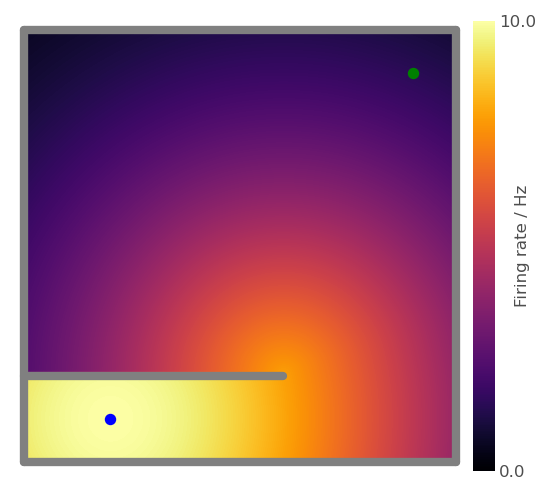

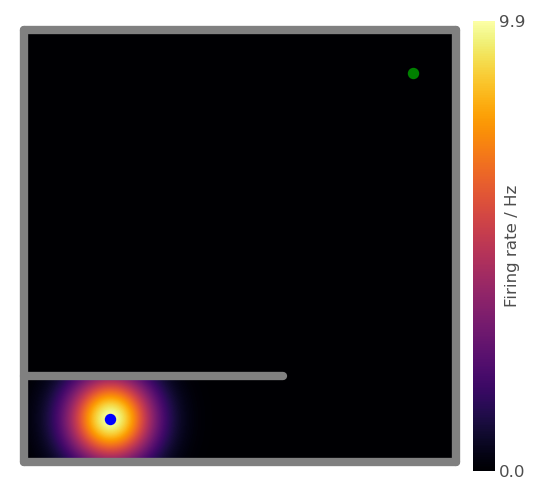

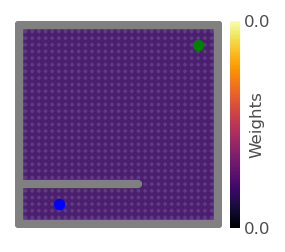

In [6]:
Env = env.OpenField(params=env_params)
Env.add_reward_objects(coords=[reward_location])
Env.add_novel_objects(coords=[novel_location])
Env.add_wall(wall_coords)

Ag = agent.OpenFieldAgent(Env, params=agent_params)
Ag.pos = np.asarray(start_location)
Ag.head_direction = np.asarray([-1, 0])
target_is_reward = Ag.target_position is not None and (Ag.target_position == reward_location).all()
print(f"Target is reward: {target_is_reward}.")

ECs = object_neurons.FixedObjectCells(Ag, params=EC_params)
CA3_PCs = riab_neurons.PlaceCells(Ag, params=CA3_PC_params)

CA1_params["dend_input_layers"] = [ECs]
CA1_params["soma_input_layers"] = [CA3_PCs]
CA1s = two_comp_neurons.TwoCompLayer(Ag, params=CA1_params)
CA1s.set_learn(False)
CA1s.set_BTSP_learn(False)

VN = value_neurons.SimpleValueNeuron(Ag, params=VN_params)
VN.plot_rate_map(no_legend=True)
ECs.plot_rate_map(no_legend=True)

plot_fcts.plot_2D_input_place_cell_weights(
    CA1s.SomaCompartment, alpha=0.3, mark_BTSP=False, no_legend=True
);

## Learn

In [7]:
CA1s.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
CA1s.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
num_BTSP_to_date = len(CA1s.SomaCompartment.history["BTSP_events"])

CA1s_weights, CA1s_weights_t = list(), list()
for i in tqdm(range(15000)):
    VN.update()
    drift_velocity = None
    if Ag.target_position is not None and (Ag.target_position == VN.peak).all():
        gradV = VN.get_local_gradient(thresh_gradV=0.2)
        if gradV is not None: 
            drift_velocity = 3 * Ag.speed_mean * gradV

    Ag.update(
        drift_velocity=drift_velocity,
        drift_to_random_strength_ratio=0.2
        )
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

    if not BTSP_started and len(Ag.trajectory_df) > 2:
        CA1s.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True

    if not i % record_weights_freq:
        CA1s_weights.append(copy.deepcopy(CA1s.SomaCompartment.inputs["CA3_PCs"]["w"]))
        CA1s_weights_t.append(Ag.t)

num_BTSP_events = len(CA1s.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

print(f"{num_BTSP_events} BTSP event(s).")
Ag.log_teleportation()
Ag.trajectory_df

100%|████████████████████████████████████| 15000/15000 [00:51<00:00, 291.26it/s]

3 BTSP event(s).
No teleportation events.


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,0.530445,0.291696,0,0.0,0.602156,0.297189,2000.0,60.0,2000.0,60.0
1,0.089757,0.764592,2000,60.0,0.266606,0.297189,4000.0,120.0,2000.0,60.0
2,0.055320,0.788498,4000,120.0,0.539629,0.297189,6000.0,180.0,2000.0,60.0
3,0.347529,0.857138,6000,180.0,0.518873,0.297189,8000.0,240.0,2000.0,60.0
4,0.393276,0.661828,8000,240.0,0.033785,0.297189,10000.0,300.0,2000.0,60.0
5,0.418865,0.554495,10000,300.0,0.055100,0.297189,12000.0,360.0,2000.0,60.0
6,0.784208,0.399878,12000,360.0,0.121953,0.297189,14000.0,420.0,2000.0,60.0
7,0.909147,0.635523,14000,420.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
Ag.target_df.head()

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,1.0,novel,1.0,0.9,0.9,0,0.00,[],216.0,6.48,0.0,0.00,216.0,6.48
1,NaN,no_target,NaN,NaN,NaN,216,6.48,"[[216, 516]]",NaN,NaN,300.0,9.00,300.0,9.00
2,NaN,no_target,NaN,NaN,NaN,516,15.48,"[[516, 816]]",NaN,NaN,300.0,9.00,300.0,9.00
3,0.0,reward,0.0,0.2,0.1,816,24.48,"[[816, 1116], [1116, 1416], [1416, 1716], [171...",NaN,NaN,1184.0,35.52,1184.0,35.52
4,1.0,novel,1.0,0.9,0.9,2000,60.00,[],2314.0,69.42,0.0,0.00,314.0,9.42


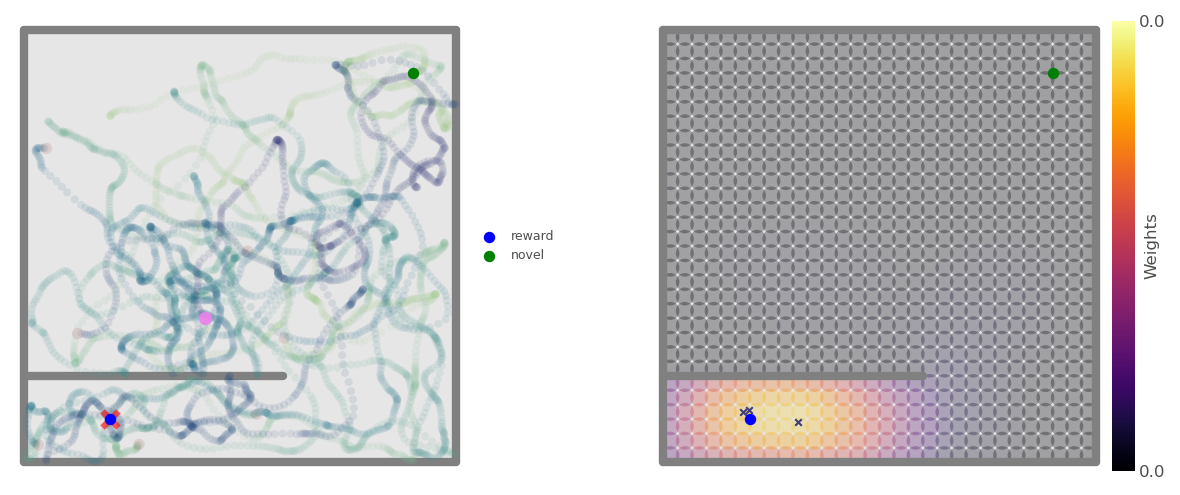

In [9]:
fig, ax1D = plt.subplots(1, 2, figsize=[8, 3])
Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0])

plot_fcts.plot_2D_input_place_cell_weights(
    CA1s.SomaCompartment, alpha=0.3, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
);

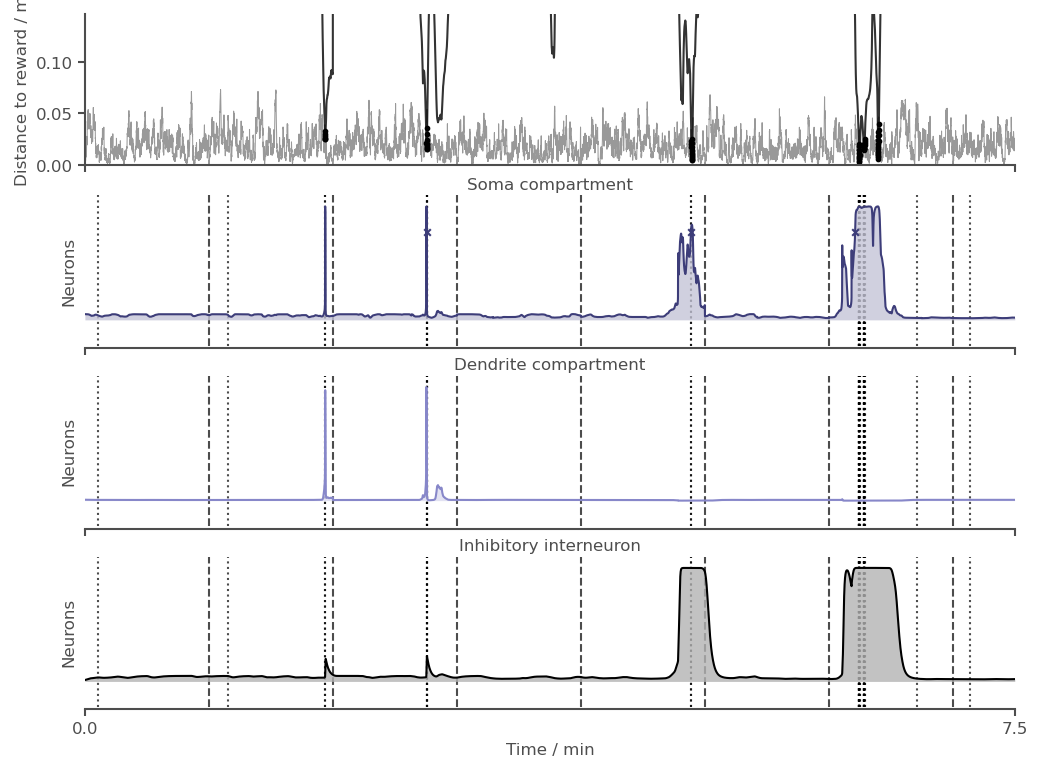

In [10]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(4, 1, figsize=[8, 6], sharex=True)
Ag.plot_distance_to(
    position_name="reward", 
    position=reward_location, 
    mark_below_tolerance=True, 
    tol_prop_to_speed_dt=tol_prop_to_speed_dt,
    zoom_prop=2,
    sub_ax=ax1D[0]
    )
ax1D[0].set_xlabel("")
CA1s.plot_rate_timeseries(separate_axes=True, ax=ax1D[1:]);

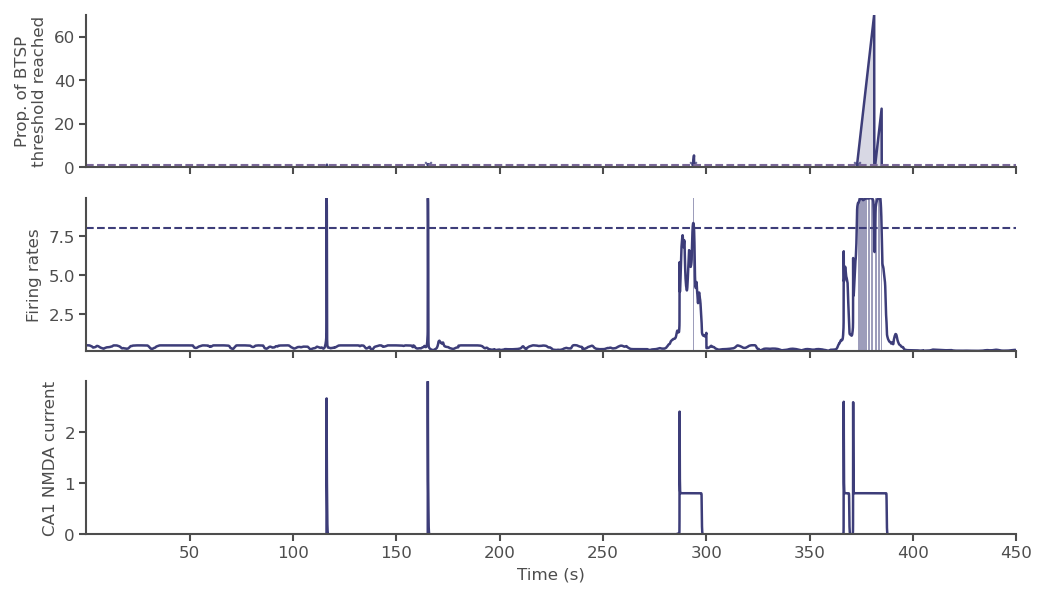

In [11]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
CA1s.SomaCompartment.plot_BTSP_ramp(axes=ax1D);

In [12]:
ANIMATE = False

In [13]:
if ANIMATE:    
    t_start = 175
    t_end = t_start + 200
    
    anim_start = time.perf_counter()
    anim = animate_util.animate(
        Ag, 
        CA1s, 
        CA1s_weights,
        CA1s_weights_t,
        t_start=t_start, 
        t_end=t_end, 
        fps=5, 
        speed_up=4, 
        environment="openfield",
        embed_limit=85.0,
        autosave=False,
        )
    anim

In [14]:
if ANIMATE:
    print(f"Took {(time.perf_counter() - anim_start) / 60:.2f} min. to generate animation.")
    ratinabox.utils.save_animation(anim, "openfield_corridor_timeseries", anim_save_types=["mp4"]); # gif doesn't work well

## Add teleportation location

In [15]:
teleport_start_time = Ag.t

if Env.num_teleport_pairs == 0:
    Env.add_teleport_pairs(coord_pairs=[teleport_in_out]) # breaks the link, but OK here

CA1s.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
CA1s.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
num_BTSP_to_date = len(CA1s.SomaCompartment.history["BTSP_events"])
for i in tqdm(range(15000)):
    VN.update()
    drift_velocity = None
    if Ag.target_position is not None and (Ag.target_position == VN.peak).all():
        gradV = VN.get_local_gradient(thresh_gradV=0.2)
        if gradV is not None: 
            drift_velocity = 3 * Ag.speed_mean * gradV

    Ag.update(
        drift_velocity=drift_velocity,
        drift_to_random_strength_ratio=0.2
        )
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

    if not BTSP_started and len(Ag.trajectory_df) > 2:
        CA1s.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True

    if not i % record_weights_freq:
        CA1s_weights.append(copy.deepcopy(CA1s.SomaCompartment.inputs["CA3_PCs"]["w"]))
        CA1s_weights_t.append(Ag.t)

num_BTSP_events = len(CA1s.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

print(f"{num_BTSP_events} BTSP event(s).")
Ag.log_teleportation()
Ag.trajectory_df

  0%|                                                 | 0/15000 [00:00<?, ?it/s]/home/cgillon/Documents/predhpc/predhpc/neurons/object_neurons.py:439: UserWarning: Object cell centres have been detached from the environment object locations, preventing them from being dynamically updated.
  warnings.warn(
 12%|████▎                                | 1733/15000 [00:05<00:46, 283.81it/s]

Teleported through pair 0 at step 16686 (500.61 sec.)


 28%|██████████▏                          | 4139/15000 [00:13<00:42, 258.29it/s]

Teleported through pair 0 at step 19100 (573.03 sec.)


 46%|████████████████▉                    | 6879/15000 [00:21<00:28, 287.58it/s]

Teleported through pair 0 at step 21825 (654.78 sec.)


100%|████████████████████████████████████| 15000/15000 [00:49<00:00, 304.57it/s]

9 BTSP event(s).
Teleportation events:
    through pair 0 at step 16686 (500.61 sec.)    
through pair 0 at step 19100 (573.03 sec.)    
through pair 0 at step 21825 (654.78 sec.)


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,0.530445,0.291696,0,0.0,0.602156,0.002273,2000.0,60.0,2000.0,60.0
1,0.089757,0.764592,2000,60.0,0.266606,0.002273,4000.0,120.0,2000.0,60.0
2,0.055320,0.788498,4000,120.0,0.539629,0.002273,6000.0,180.0,2000.0,60.0
3,0.347529,0.857138,6000,180.0,0.518873,0.002273,8000.0,240.0,2000.0,60.0
4,0.393276,0.661828,8000,240.0,0.033785,0.002273,10000.0,300.0,2000.0,60.0
5,0.418865,0.554495,10000,300.0,0.055100,0.002273,12000.0,360.0,2000.0,60.0
6,0.784208,0.399878,12000,360.0,0.121953,0.002273,14000.0,420.0,2000.0,60.0
7,0.909147,0.635523,14000,420.0,0.387475,0.002273,16000.0,480.0,2000.0,60.0
8,0.728294,0.782320,16000,480.0,0.278691,0.002273,18000.0,540.0,2000.0,60.0
9,0.365501,0.291851,18000,540.0,0.881844,0.002273,20000.0,600.0,2000.0,60.0


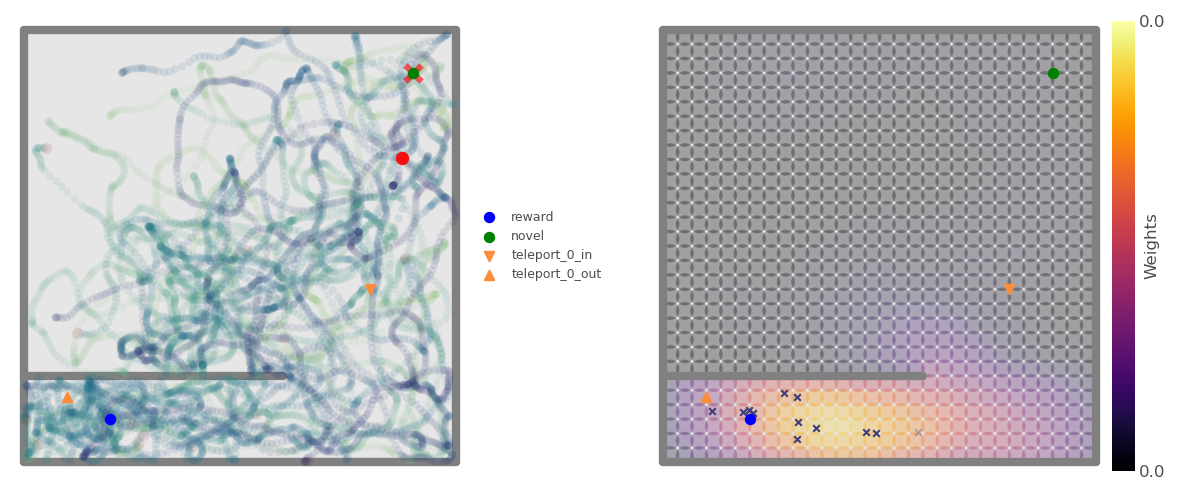

In [16]:
fig, ax1D = plt.subplots(1, 2, figsize=[8, 3])
Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0])

plot_fcts.plot_2D_input_place_cell_weights(
    CA1s.SomaCompartment, alpha=0.3, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
);

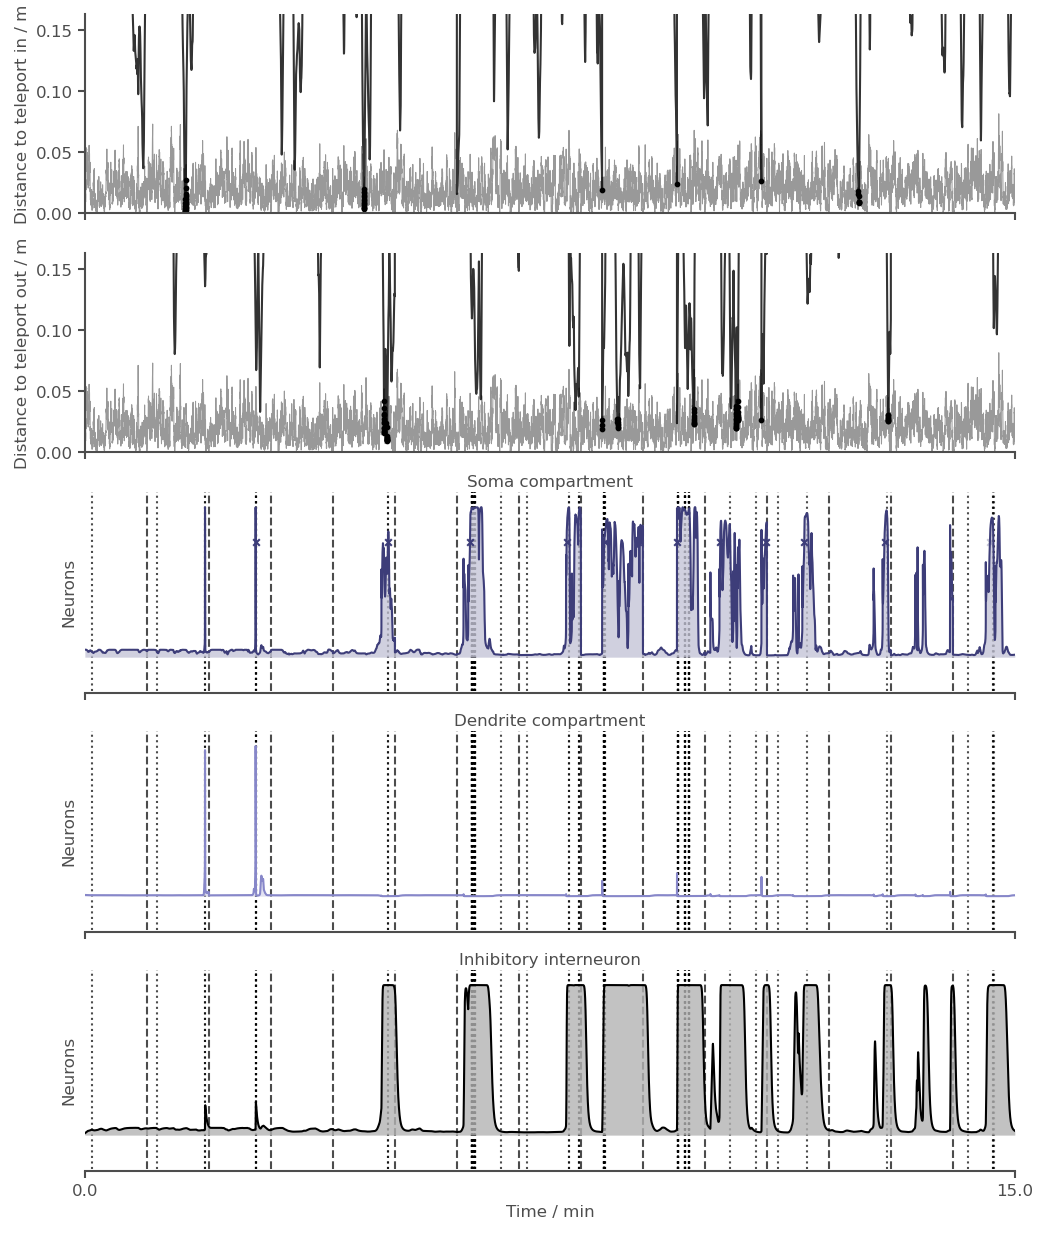

In [17]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(5, 1, figsize=[8, 10], sharex=True)
for i, (direc, teleport) in enumerate(zip(["in", "out"], teleport_in_out)):
    Ag.plot_distance_to(
        position_name=f"teleport {direc}", 
        position=teleport, 
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        sub_ax=ax1D[i]
    )
    ax1D[i].set_xlabel("")

CA1s.plot_rate_timeseries(separate_axes=True, ax=ax1D[2:]);

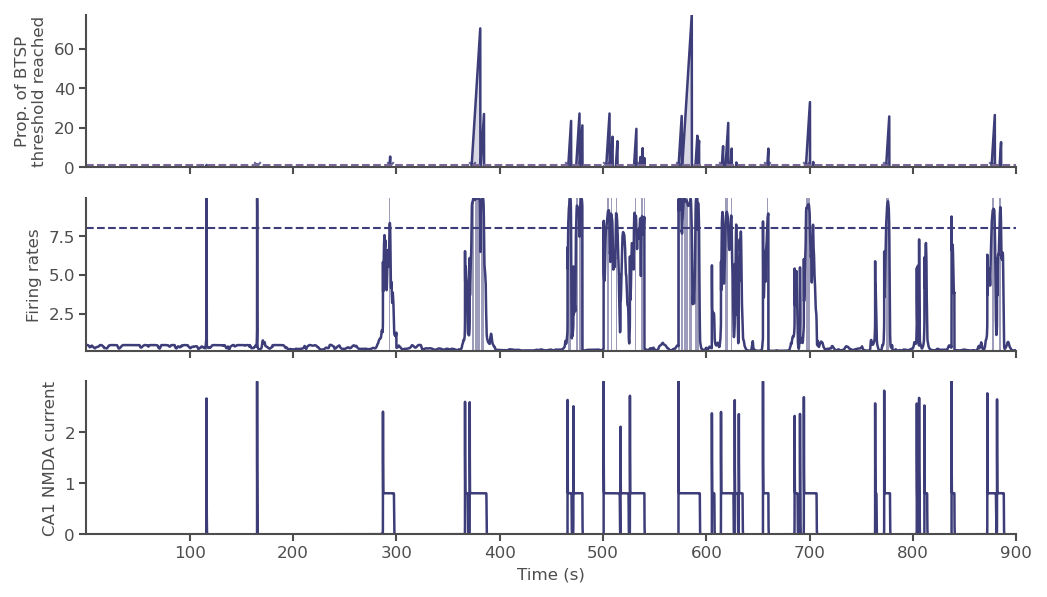

In [18]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
CA1s.SomaCompartment.plot_BTSP_ramp(axes=ax1D);

In [19]:
ANIMATE = False

In [20]:
if ANIMATE:
    t_start = 425
    t_end = t_start + 200
    
    anim_start = time.perf_counter()
    anim = animate_util.animate(
        Ag, 
        CA1s, 
        CA1s_weights,
        CA1s_weights_t,
        t_start=t_start, 
        t_end=t_end, 
        fps=5, 
        speed_up=4, 
        environment="openfield",
        embed_limit=85.0,
        autosave=False,
        )
    anim

In [21]:
if ANIMATE:
    print(f"Took {(time.perf_counter() - anim_start) / 60:.2f} min. to generate animation.")
    ratinabox.utils.save_animation(anim, "openfield_corridor_timeseries_teleport", anim_save_types=["mp4"]); # gif doesn't work well